# Validación sintética de `is_reliable` y calibración del umbral

`evaluate.ipynb` mostró que el conjunto de evaluación natural (5 documentos SRI) no contiene ni un solo error de asociación (`fp=0` en form y en tablas), y que ningún campo/celda con múltiples candidatos disponibles llegó nunca a `is_reliable=False`. Eso impide demostrar empíricamente, con datos naturales, que el indicador `is_reliable` diferencia asociaciones fiables de potencialmente incorrectas — no porque el indicador esté mal, sino porque el conjunto natural no tiene variación que discriminar.

Este notebook resuelve eso con **casos sintéticos controlados**, generados a partir de la geometría real usada por `KeyValueExtractor._score_value_candidate`, para:

1. Generar un barrido sistemático de casos con distinto grado de ambigüedad (no solo ejemplos extremos elegidos a mano).
2. Construir la curva cobertura-precisión que justifica el valor de `AMBIGUITY_K` (margen relativo mínimo) configurado en `.env`.
3. Ilustrar con 3 casos concretos (control / ambigüedad real / confiadamente equivocado) qué significa cada zona de la curva.

**Contexto:** `_is_reliable` fue reformulado de un criterio basado en desviación estándar (que resultaba matemáticamente incapaz de detectar ambigüedad con exactamente 2 candidatos, sin importar `K`) a un **margen relativo**: `(mejor - segundo) / mejor > K`. Este notebook también sirve para calibrar `K` con evidencia, no a ojo.

In [2]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path().resolve()
while ROOT.name != "pdf-key-extraction":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))
os.chdir(ROOT)

from extract.key_value_extractor import KeyValueExtractor

extractor = KeyValueExtractor()
print(f"AMBIGUITY_K configurado en .env = {extractor.AMBIGUITY_K}")

c:\Users\Samuel\miniconda3\envs\pdf-key-extraction\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AMBIGUITY_K configurado en .env = 0.1


## 1. Generación paramétrica de casos sintéticos

Fijamos una clave (`FIELD_KEY_AMOUNT "TOTAL:"`) y un valor correcto (`"45.00"`) alineado debajo de la clave (tier=1, distancia=100 en el espacio normalizado). Generamos un candidato "decoy" incorrecto en la misma columna, variando su distancia como una fracción `factor` de la distancia del valor correcto:

- `factor < 1` → el decoy está más cerca de la clave que el valor correcto → el decoy **gana** (caso incorrecto).
- `factor > 1` → el decoy está más lejos → el valor correcto **gana** (caso correcto).
- `factor ≈ 1` → casi empatados (ambigüedad real).

Los scores se calculan con el método real `extractor._score_value_candidate`, no con una fórmula reimplementada aparte — así no hay riesgo de que el análisis se desvíe del comportamiento real del sistema.

In [3]:
KEY_BBOX = (60, 400, 140, 415)          # "TOTAL:"
TRUE_VALUE_BBOX = (80, 500, 120, 515)    # "45.00", alineado debajo, centrado


def decoy_bbox(factor: float):
    """Bbox de un candidato incorrecto a `factor` veces la distancia del valor correcto."""
    center_y = 407.5 + 100 * factor
    y0 = center_y - 7.5
    return (80, y0, 120, y0 + 15)


true_score = extractor._score_value_candidate(KEY_BBOX, TRUE_VALUE_BBOX)
print(f"score del valor correcto (factor=1): {true_score}")

score del valor correcto (factor=1): 1900.0


In [4]:
factors = np.linspace(0.3, 3.0, 80)

records = []
for factor in factors:
    decoy_score = extractor._score_value_candidate(KEY_BBOX, decoy_bbox(factor))
    scores = [true_score, decoy_score]
    best_score, second_score = sorted(scores, reverse=True)[:2]
    relative_margin = (best_score - second_score) / best_score
    correct = true_score >= decoy_score  # el valor correcto gano el score mas alto

    records.append({
        "factor": factor,
        "true_score": true_score,
        "decoy_score": decoy_score,
        "relative_margin": relative_margin,
        "correct": correct,
    })

cases_df = pd.DataFrame(records)
cases_df.head()

,factor,true_score,decoy_score,relative_margin,correct
0,0.300000,1900.0,1970.000000,0.035533,False
1,0.334177,1900.0,1966.582278,0.033857,False
2,0.368354,1900.0,1963.164557,0.032175,False
3,0.402532,1900.0,1959.746835,0.030487,False
4,0.436709,1900.0,1956.329114,0.028793,False


## 2. Verificacion: el calculo manual coincide con `_is_reliable` real

Antes de confiar en el barrido, confirmamos que aplicar `relative_margin > K` a mano reproduce exactamente lo que devuelve `extractor._is_reliable` con el `K` configurado actualmente.

In [5]:
sample = cases_df.sample(10, random_state=0)
for _, row in sample.iterrows():
    candidates = [
        {"score": row["true_score"]},
        {"score": row["decoy_score"]},
    ]
    real = extractor._is_reliable(candidates)
    manual = row["relative_margin"] > extractor.AMBIGUITY_K
    assert real == manual, f"discrepancia en factor={row['factor']}"

print("OK: el calculo manual coincide con _is_reliable en los 10 casos muestreados.")

OK: el calculo manual coincide con _is_reliable en los 10 casos muestreados.


## 3. Barrido de umbral y curva cobertura-precision

Para cada umbral candidato `T`, calculamos:

- **Cobertura(T)**: fraccion de casos que el sistema marcaria como `is_reliable=True` con ese umbral.
- **Precision(T)**: de esos marcados confiables, que fraccion realmente acerto (eligio el valor correcto).

In [6]:
thresholds = np.linspace(0.0, 0.30, 61)

curve_records = []
for t in thresholds:
    flagged = cases_df["relative_margin"] > t
    coverage = flagged.mean()
    precision = cases_df.loc[flagged, "correct"].mean() if flagged.any() else float("nan")
    curve_records.append({"threshold": t, "coverage": coverage, "precision": precision})

curve_df = pd.DataFrame(curve_records)
curve_df.head()

,threshold,coverage,precision
0,0.000,1.000,0.737500
1,0.005,0.925,0.756757
2,0.010,0.850,0.779412
3,0.015,0.800,0.796875
4,0.020,0.725,0.827586


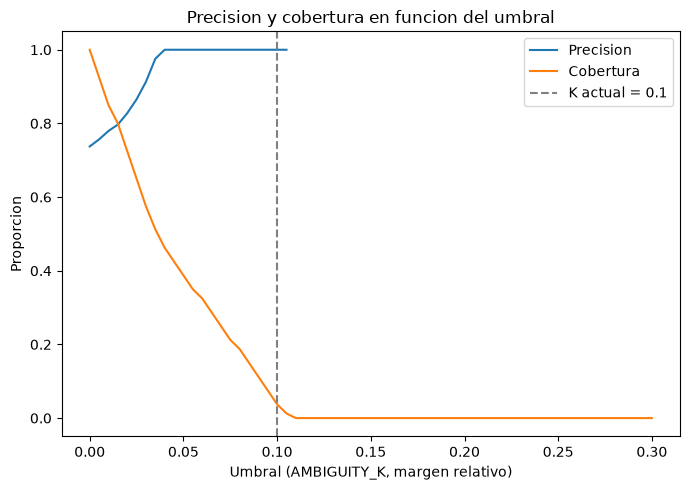

In [7]:
fig, ax1 = plt.subplots(figsize=(7, 5))

ax1.plot(curve_df["threshold"], curve_df["precision"], label="Precision", color="tab:blue")
ax1.plot(curve_df["threshold"], curve_df["coverage"], label="Cobertura", color="tab:orange")
ax1.axvline(extractor.AMBIGUITY_K, color="gray", linestyle="--", label=f"K actual = {extractor.AMBIGUITY_K}")
ax1.set_xlabel("Umbral (AMBIGUITY_K, margen relativo)")
ax1.set_ylabel("Proporcion")
ax1.set_title("Precision y cobertura en funcion del umbral")
ax1.legend()
plt.tight_layout()
plt.show()

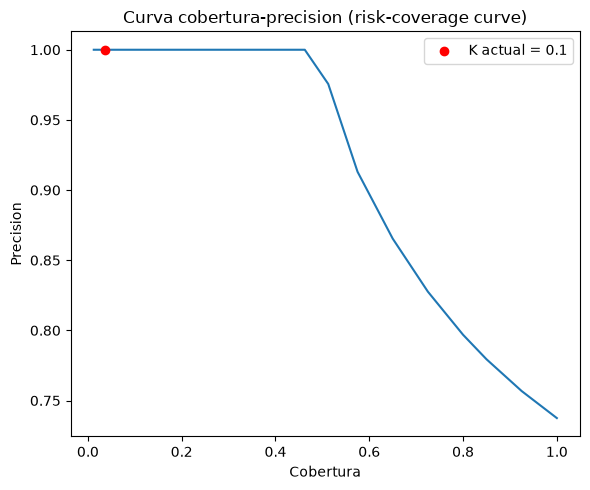

In [8]:
plt.figure(figsize=(6, 5))
plt.plot(curve_df["coverage"], curve_df["precision"])
current = curve_df.iloc[(curve_df["threshold"] - extractor.AMBIGUITY_K).abs().idxmin()]
plt.scatter([current["coverage"]], [current["precision"]], color="red", zorder=5,
            label=f"K actual = {extractor.AMBIGUITY_K}")
plt.xlabel("Cobertura")
plt.ylabel("Precision")
plt.title("Curva cobertura-precision (risk-coverage curve)")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Tabla de referencia para justificar el umbral

In [9]:
reference_thresholds = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
reference_rows = []
for t in reference_thresholds:
    flagged = cases_df["relative_margin"] > t
    reference_rows.append({
        "threshold": t,
        "coverage": flagged.mean(),
        "precision": cases_df.loc[flagged, "correct"].mean() if flagged.any() else float("nan"),
    })

pd.DataFrame(reference_rows)

,threshold,coverage,precision
0,0.00,1.0000,0.7375
1,0.05,0.3875,1.0000
2,0.10,0.0375,1.0000
3,0.15,0.0000,NaN
4,0.20,0.0000,NaN
5,0.25,0.0000,NaN
6,0.30,0.0000,NaN


## 5. Casos ilustrativos concretos (control / ambiguedad real / confiadamente equivocado)

Tres casos puntuales, guardados en `evaluate/synthetic/adversarial_cases.json`, uno por pagina, que ilustran zonas especificas de la curva anterior con datos reales pasados por `apply_heuristic` (no solo el calculo de scores en aislado).

In [10]:
from collections import defaultdict


def load_gold_results(json_path: Path):
    with open(json_path, encoding="utf-8") as f:
        entities = json.load(f)
    by_page = defaultdict(list)
    for e in entities:
        by_page[e["page"]].append(e)
    results = []
    for page, page_entities in sorted(by_page.items()):
        results.append({
            "page": page,
            "words": [e["text"] for e in page_entities],
            "boxes": [e["normalized_bbox"] for e in page_entities],
            "labels": [e["label"] for e in page_entities],
        })
    return results


adversarial_path = ROOT / "evaluate" / "synthetic" / "adversarial_cases.json"
synthetic_out = extractor.apply_heuristic(load_gold_results(adversarial_path))

scenario_names = ["A - control", "B - ambiguedad real", "C - confiadamente equivocado"]
scenario_gold = [45.0, 45.0, 45.0]

illustrative_rows = []
for name, gold, entry in zip(scenario_names, scenario_gold, synthetic_out["form"]):
    illustrative_rows.append({
        "escenario": name,
        "valor_elegido": entry["value"],
        "correcto": entry["value"] == gold,
        "is_reliable": entry["is_reliable"],
        "candidatos": entry["candidates"],
    })

pd.DataFrame(illustrative_rows)

,escenario,valor_elegido,correcto,is_reliable,candidatos
0,A - control,45.0,True,True,"[{'value': 45.0, 'score': 2130.0}, {'value': 1..."
1,B - ambiguedad real,45.0,True,False,"[{'value': 45.0, 'score': 2130.0}, {'value': 1..."
2,C - confiadamente equivocado,12.0,False,True,"[{'value': 12.0, 'score': 2130.0}, {'value': 4..."
